# Smart Helmet — Mine Safety Decision Tree
**Sensors:** DHT11 (temp + humidity) | MQ135 (gas) | BMI160 (acc + gyro)  
**Classes:** NORMAL | WARNING | EMERGENCY  
**Goal:** Train a Decision Tree → Export as C header for ESP32 WROOM

## Cell 1 — Install & Import Libraries

In [ ]:
# Run this cell once to install dependencies
# If already installed, skip this cell
# !pip install scikit-learn numpy pandas matplotlib seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Jupyter inline plots
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

RANDOM_SEED = 42
TEST_SIZE   = 0.20
np.random.seed(RANDOM_SEED)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Cell 2 — Load Dataset

In [2]:
DATASET_PATH = r'D:\IoT_Project\smart_helmet_mine_dataset.csv'
OUTPUT_DIR   = r'D:\IoT_Project\outputs'
PLOT_DIR     = r'D:\IoT_Project\outputs\plots'
ARDUINO_DIR  = r'D:\IoT_Project\Arduino\smart_helmet_dt'

os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(PLOT_DIR,    exist_ok=True)
os.makedirs(ARDUINO_DIR, exist_ok=True)

df = pd.read_csv(DATASET_PATH)
print(f'Shape  : {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape  : (5500, 16)
Columns: ['sample_id', 'timestamp', 'temperature_C', 'humidity_pct', 'gas_ppm', 'acc_x_g', 'acc_y_g', 'acc_z_g', 'acc_resultant_g', 'gyro_x_dps', 'gyro_y_dps', 'gyro_z_dps', 'gyro_resultant_dps', 'risk_score', 'scenario', 'label']


,sample_id,timestamp,temperature_C,humidity_pct,gas_ppm,acc_x_g,acc_y_g,acc_z_g,acc_resultant_g,gyro_x_dps,gyro_y_dps,gyro_z_dps,gyro_resultant_dps,risk_score,scenario,label
0,1,2024-01-08 11:03:55,27.0,84.0,3871.6,-1.4922,0.3480,3.5546,3.8708,-78.698,-45.490,-40.561,132.945,0.4965,gas_eruption,WARNING
1,2,2024-01-01 07:39:55,28.0,83.0,802.4,-0.0807,-0.0177,1.8424,1.8443,-2.025,-0.902,-0.697,3.379,0.1420,shift_normal_walking,NORMAL
2,3,2024-01-10 15:06:00,30.0,95.0,2787.3,0.0400,0.1899,0.4660,0.5048,-3.534,-1.044,-0.959,5.429,0.4005,worker_incapacitated,WARNING
3,4,2024-01-07 09:12:15,49.0,55.0,4095.0,3.9029,0.9734,-2.3404,4.6538,-40.520,-39.670,-17.085,129.402,1.0000,active_mine_fire,EMERGENCY
4,5,2024-01-01 08:05:10,35.0,85.0,813.6,-0.9396,-1.4118,-0.6282,1.8085,20.014,7.406,-11.950,31.612,0.1698,shift_heavy_work,NORMAL


label
NORMAL       3255
WARNING      1460
EMERGENCY     785
Name: count, dtype: int64


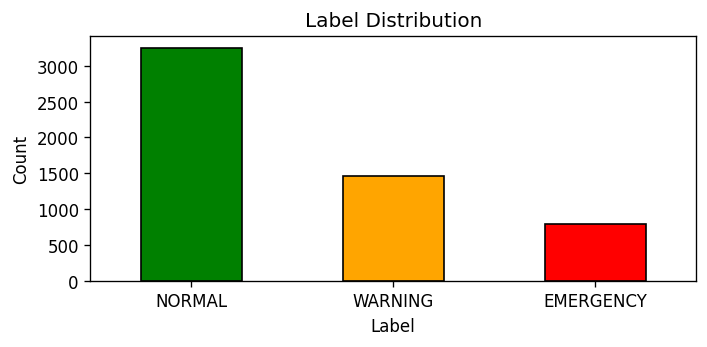

In [3]:
# Label distribution
label_counts = df['label'].value_counts()
print(label_counts)

plt.figure(figsize=(6, 3))
label_counts.plot(kind='bar', color=['green', 'orange', 'red'], edgecolor='black')
plt.title('Label Distribution')
plt.xlabel('Label'); plt.ylabel('Count')
plt.xticks(rotation=0); plt.tight_layout()
plt.show()

## Cell 3 — Prepare Features & Split

In [4]:
FEATURE_COLS = [
    'temperature_C',
    'humidity_pct',
    'gas_ppm',
    'acc_x_g', 'acc_y_g', 'acc_z_g', 'acc_resultant_g',
    'gyro_x_dps', 'gyro_y_dps', 'gyro_z_dps', 'gyro_resultant_dps',
]

X  = df[FEATURE_COLS].values.astype(np.float32)
le = LabelEncoder()
y  = le.fit_transform(df['label'].values)

print('Class mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')

# No normalization needed for Decision Tree!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y)

print(f'\nTrain : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')

Class mapping:
  0 → EMERGENCY
  1 → NORMAL
  2 → WARNING

Train : 4400 samples
Test  : 1100 samples


## Cell 4 — Find Optimal Tree Depth

Best depth : 11
Best CV acc: 0.9277


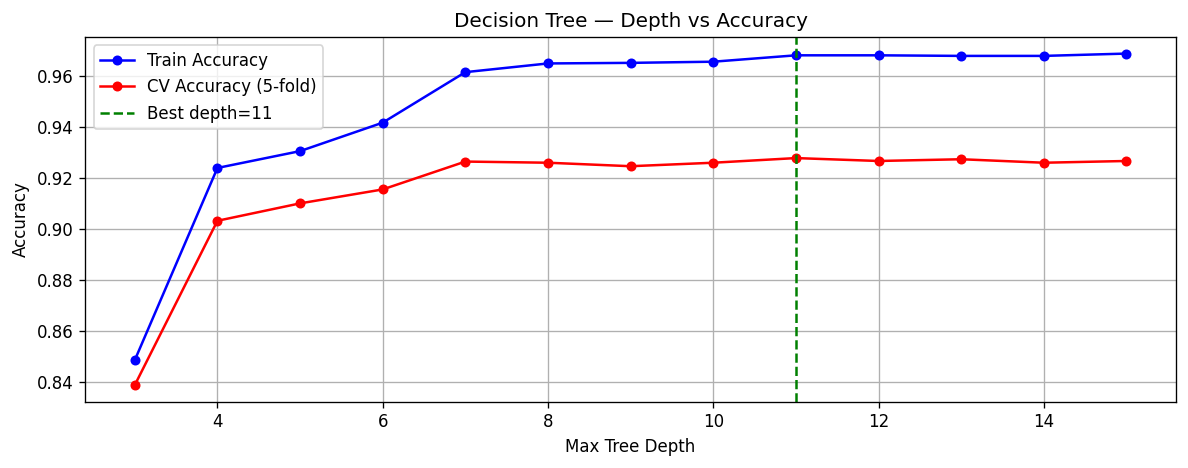

In [5]:
depths       = range(3, 16)
cv_scores    = []
train_scores = []
node_counts  = []

for d in depths:
    dt_temp = DecisionTreeClassifier(
        max_depth=d, criterion='gini',
        min_samples_split=10, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_SEED)
    cv = cross_val_score(dt_temp, X_train, y_train, cv=5, scoring='accuracy')
    dt_temp.fit(X_train, y_train)
    tr = accuracy_score(y_train, dt_temp.predict(X_train))
    cv_scores.append(cv.mean())
    train_scores.append(tr)
    node_counts.append(dt_temp.tree_.node_count)

best_depth = list(depths)[np.argmax(cv_scores)]
print(f'Best depth : {best_depth}')
print(f'Best CV acc: {max(cv_scores):.4f}')

# Plot
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(depths, train_scores, 'b-o', label='Train Accuracy', markersize=5)
ax1.plot(depths, cv_scores,    'r-o', label='CV Accuracy (5-fold)', markersize=5)
ax1.axvline(x=best_depth, color='green', linestyle='--', label=f'Best depth={best_depth}')
ax1.set_xlabel('Max Tree Depth'); ax1.set_ylabel('Accuracy')
ax1.set_title('Decision Tree — Depth vs Accuracy')
ax1.legend(); ax1.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'depth_vs_accuracy.png'), dpi=150)
plt.show()

## Cell 5 — Train Final Model

In [6]:
dt = DecisionTreeClassifier(
    max_depth=best_depth, criterion='gini',
    min_samples_split=10, min_samples_leaf=5,
    class_weight='balanced', random_state=RANDOM_SEED)
dt.fit(X_train, y_train)

y_pred    = dt.predict(X_test)
train_acc = accuracy_score(y_train, dt.predict(X_train))
test_acc  = accuracy_score(y_test,  y_pred)

print(f'Train Accuracy : {train_acc*100:.2f}%')
print(f'Test  Accuracy : {test_acc*100:.2f}%')
print(f'Tree Nodes     : {dt.tree_.node_count}')
print(f'Tree Depth     : {best_depth}')

Train Accuracy : 96.80%
Test  Accuracy : 93.18%
Tree Nodes     : 233
Tree Depth     : 11


## Cell 6 — Classification Report

In [7]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

   EMERGENCY       0.86      0.93      0.90       157
      NORMAL       0.98      0.96      0.97       651
     WARNING       0.87      0.87      0.87       292

    accuracy                           0.93      1100
   macro avg       0.90      0.92      0.91      1100
weighted avg       0.93      0.93      0.93      1100



## Cell 7 — Confusion Matrix

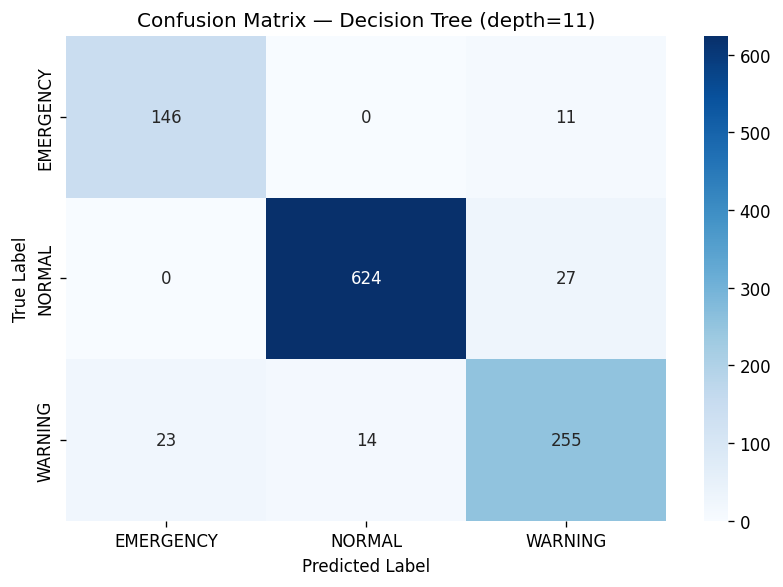

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — Decision Tree (depth={best_depth})')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'confusion_matrix_dt.png'), dpi=150)
plt.show()

## Cell 8 — Feature Importance

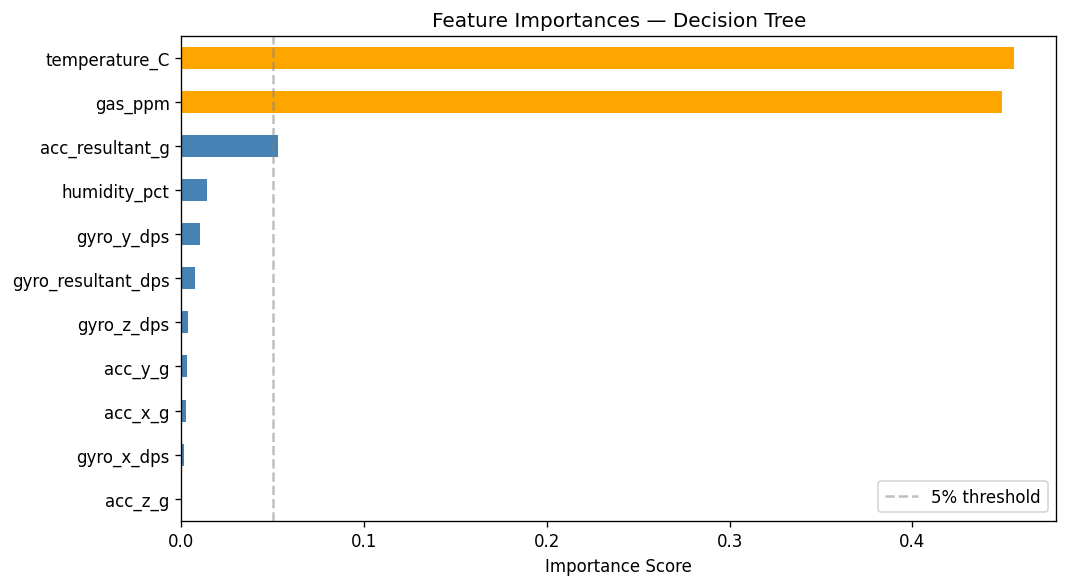


Importance values:
  temperature_C             0.4558  ██████████████████
  gas_ppm                   0.4490  █████████████████
  acc_resultant_g           0.0528  ██
  humidity_pct              0.0138  
  gyro_y_dps                0.0103  
  gyro_resultant_dps        0.0074  
  gyro_z_dps                0.0036  
  acc_y_g                   0.0033  
  acc_x_g                   0.0023  
  gyro_x_dps                0.0014  
  acc_z_g                   0.0002  


In [9]:
fi = pd.Series(dt.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
colors = ['red' if v > 0.5 else 'orange' if v > 0.1 else 'steelblue' for v in fi.values]
fi.plot(kind='barh', color=colors)
plt.title('Feature Importances — Decision Tree')
plt.xlabel('Importance Score')
plt.axvline(x=0.05, color='gray', linestyle='--', alpha=0.5, label='5% threshold')
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'feature_importance.png'), dpi=150)
plt.show()

print('\nImportance values:')
for feat, imp in fi.sort_values(ascending=False).items():
    bar = '█' * int(imp * 40)
    print(f'  {feat:<25} {imp:.4f}  {bar}')

## Cell 9 — Visualize the Decision Tree

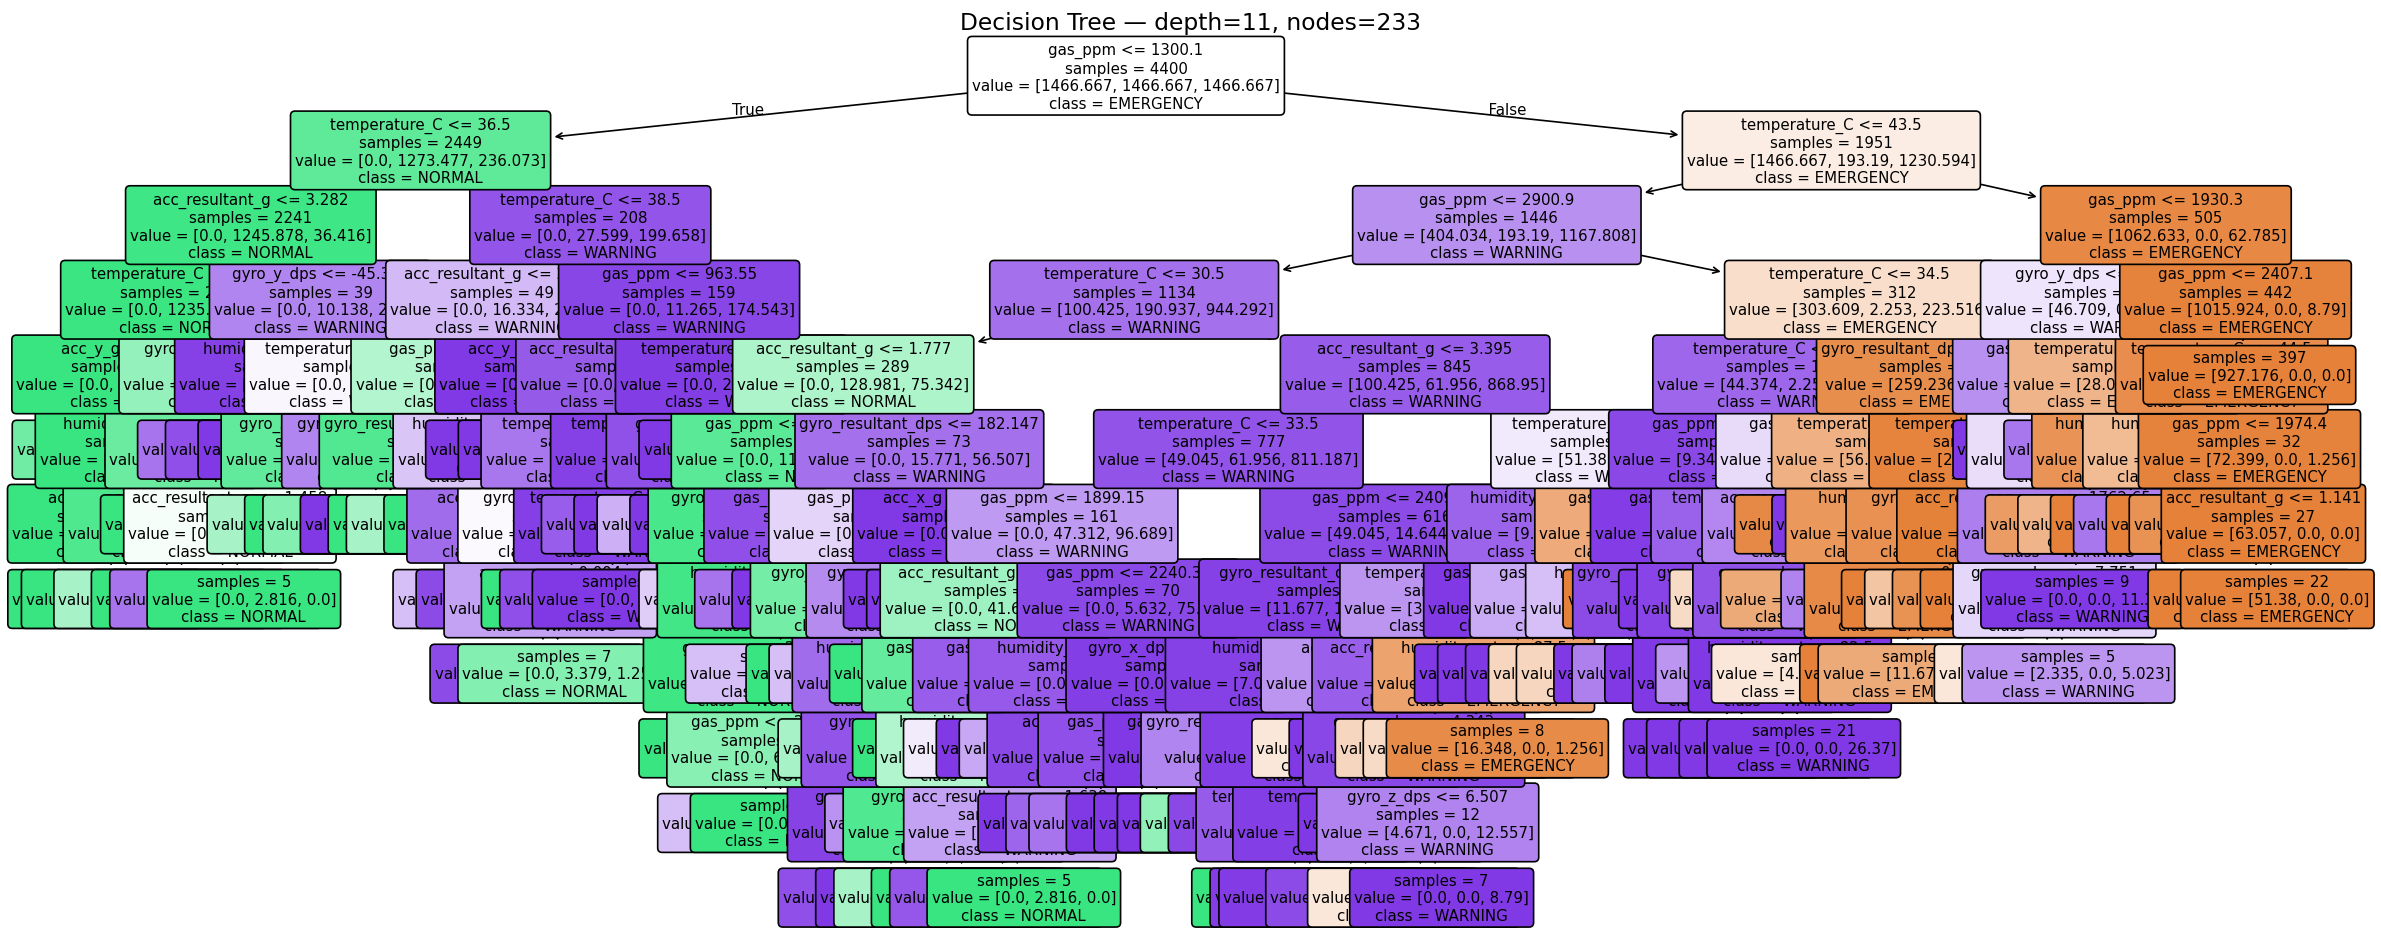

In [10]:
# Visual tree diagram — unique to Jupyter, not possible in plain .py!
plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=FEATURE_COLS,
    class_names=list(le.classes_),
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=False
)
plt.title(f'Decision Tree — depth={best_depth}, nodes={dt.tree_.node_count}', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'decision_tree_diagram.png'), dpi=150, bbox_inches='tight')
plt.show()

## Cell 10 — Human-Readable Tree Rules

In [11]:
tree_rules = export_text(dt, feature_names=FEATURE_COLS)
print(tree_rules)

# Save to file
rules_path = os.path.join(OUTPUT_DIR, 'tree_rules.txt')
with open(rules_path, 'w', encoding='utf-8') as f:
    f.write(f'Decision Tree Rules (depth={best_depth})\n')
    f.write(f'Train Accuracy: {train_acc*100:.2f}%\n')
    f.write(f'Test  Accuracy: {test_acc*100:.2f}%\n')
    f.write(f'Nodes: {dt.tree_.node_count}\n\n')
    f.write(f'Class mapping: {dict(enumerate(le.classes_))}\n\n')
    f.write(tree_rules)
print(f'Saved → {rules_path}')

|--- gas_ppm <= 1300.10
|   |--- temperature_C <= 36.50
|   |   |--- acc_resultant_g <= 3.28
|   |   |   |--- temperature_C <= 35.50
|   |   |   |   |--- acc_y_g <= -2.13
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- acc_y_g >  -2.13
|   |   |   |   |   |--- humidity_pct <= 91.50
|   |   |   |   |   |   |--- acc_z_g <= -2.33
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- acc_z_g >  -2.33
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- humidity_pct >  91.50
|   |   |   |   |   |   |--- acc_z_g <= -1.47
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- acc_z_g >  -1.47
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |--- temperature_C >  35.50
|   |   |   |   |--- gyro_x_dps <= 30.31
|   |   |   |   |   |--- acc_x_g <= 0.40
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- acc_x_g >  0.40
|   |   |   |   |   |   |--- acc_resultant_g <= 1.46
|   |   |   |   |   |   |   |--- class: 2
|   |   |   |  

## Cell 11 — Export Decision Tree as C Header for ESP32

In [12]:
def tree_to_c(tree, feature_names, class_names, indent=2):
    """Walk sklearn tree structure and emit nested C if/else code"""
    tree_  = tree.tree_
    lines  = []

    def recurse(node, depth):
        pad = ' ' * (indent * depth)
        if tree_.children_left[node] == -1:  # Leaf node
            class_idx  = np.argmax(tree_.value[node][0])
            class_name = class_names[class_idx]
            total      = tree_.n_node_samples[node]
            correct    = int(tree_.value[node][0][class_idx])
            conf       = correct / total if total > 0 else 0
            lines.append(f'{pad}return {class_idx};  '
                         f'// {class_name} '
                         f'(samples={total}, confidence={conf:.2f})')
            return
        feat      = feature_names[tree_.feature[node]]
        threshold = tree_.threshold[node]
        lines.append(f'{pad}if (features[{tree_.feature[node]}] <= {threshold:.6f}f) {{  // {feat} <= {threshold:.4f}')
        recurse(tree_.children_left[node],  depth + 1)
        lines.append(f'{pad}}} else {{  // {feat} > {threshold:.4f}')
        recurse(tree_.children_right[node], depth + 1)
        lines.append(f'{pad}}}')

    recurse(0, 0)
    return '\n'.join(lines)


c_tree_body = tree_to_c(dt, FEATURE_COLS, list(le.classes_))
print('C tree body generated ')
print(f'Lines of C code: {len(c_tree_body.splitlines())}')

C tree body generated 
Lines of C code: 465


In [13]:
header_lines = []
header_lines.append('// ============================================================')
header_lines.append('//  AUTO-GENERATED — Smart Helmet Mine Safety')
header_lines.append('//  Decision Tree Model — ESP32 WROOM')
header_lines.append('//')
header_lines.append(f'//  Generated from : {DATASET_PATH}')
header_lines.append(f'//  Train accuracy : {train_acc*100:.2f}%')
header_lines.append(f'//  Test  accuracy : {test_acc*100:.2f}%')
header_lines.append(f'//  Tree depth     : {best_depth}')
header_lines.append(f'//  Tree nodes     : {dt.tree_.node_count}')
header_lines.append('//')
header_lines.append('//  Place in: D:\\IoT_Project\\Arduino\\smart_helmet_dt\\')
header_lines.append('//  features[] array order (MUST match exactly):')
for i, f in enumerate(FEATURE_COLS):
    header_lines.append(f'//    features[{i:2d}] = {f}')
header_lines.append('//')
header_lines.append('//  NO normalization needed — raw sensor values go straight in!')
header_lines.append('//  NO TFLite library needed — pure C if/else logic')
header_lines.append('// ============================================================')
header_lines.append('')
header_lines.append('#ifndef DECISION_TREE_MODEL_H')
header_lines.append('#define DECISION_TREE_MODEL_H')
header_lines.append('')
header_lines.append(f'#define NUM_FEATURES  {len(FEATURE_COLS)}')
header_lines.append(f'#define NUM_CLASSES   {len(le.classes_)}')
header_lines.append('')
header_lines.append('// Class index → label')
for i, cls in enumerate(le.classes_):
    header_lines.append(f'// {i} = {cls}')
labels_str = ', '.join([f'"{c}"' for c in le.classes_])
header_lines.append(f'const char* CLASS_LABELS[NUM_CLASSES] = {{ {labels_str} }};')
header_lines.append('')
feat_str = ', '.join([f'"{f}"' for f in FEATURE_COLS])
header_lines.append(f'const char* FEATURE_NAMES[NUM_FEATURES] = {{ {feat_str} }};')
header_lines.append('')
header_lines.append('// Safety thresholds — mine environment')
header_lines.append('#define TEMP_WARNING_THRESH    35.0f')
header_lines.append('#define TEMP_EMERGENCY_THRESH  50.0f')
header_lines.append('#define GAS_WARNING_THRESH     1000.0f')
header_lines.append('#define GAS_EMERGENCY_THRESH   3000.0f')
header_lines.append('#define ACC_WARNING_THRESH     2.0f')
header_lines.append('#define ACC_EMERGENCY_THRESH   4.0f')
header_lines.append('#define GYRO_WARNING_THRESH    60.0f')
header_lines.append('#define GYRO_EMERGENCY_THRESH  200.0f')
header_lines.append('')
header_lines.append('int predict(float features[NUM_FEATURES]) {')
header_lines.append(c_tree_body)
header_lines.append('}')
header_lines.append('')
header_lines.append('int safety_override(float features[NUM_FEATURES], int prediction) {')
header_lines.append('  bool hard_emergency = (features[0] >= TEMP_EMERGENCY_THRESH) ||')
header_lines.append('                        (features[2] >= GAS_EMERGENCY_THRESH)  ||')
header_lines.append('                        (features[6] >= ACC_EMERGENCY_THRESH && features[10] >= GYRO_EMERGENCY_THRESH);')
header_lines.append('  if (hard_emergency) return 0;')
header_lines.append('')
header_lines.append('  bool hard_warning = (features[0] >= TEMP_WARNING_THRESH) ||')
header_lines.append('                      (features[2] >= GAS_WARNING_THRESH)  ||')
header_lines.append('                      (features[6] >= ACC_WARNING_THRESH);')
header_lines.append('  if (hard_warning && prediction == 1) return 2;')
header_lines.append('')
header_lines.append('  return prediction;')
header_lines.append('}')
header_lines.append('')
header_lines.append('#endif // DECISION_TREE_MODEL_H')

header_code = '\n'.join(header_lines)

# Save to outputs folder
header_out = os.path.join(OUTPUT_DIR, 'decision_tree_model.h')
with open(header_out, 'w', encoding='utf-8') as f:
    f.write(header_code)

# Auto-copy to Arduino folder
arduino_header = os.path.join(ARDUINO_DIR, 'decision_tree_model.h')
with open(arduino_header, 'w', encoding='utf-8') as f:
    f.write(header_code)

print(f'Saved  → {header_out}')
print(f'Copied → {arduino_header}')
print(f'Size   : {len(header_code.encode())/1024:.1f} KB')

Saved  → D:\IoT_Project\outputs\decision_tree_model.h
Copied → D:\IoT_Project\Arduino\smart_helmet_dt\decision_tree_model.h
Size   : 25.1 KB


## Cell 12 — Final Summary

In [14]:
print('=' * 55)
print('  DONE — All outputs saved to D:\\IoT_Project\\outputs\\')
print('=' * 55)
print(f'  Train accuracy : {train_acc*100:.2f}%')
print(f'  Test  accuracy : {test_acc*100:.2f}%')
print(f'  Tree depth     : {best_depth}')
print(f'  Tree nodes     : {dt.tree_.node_count}')
print()
print('  Files generated:')
print(f'    outputs/decision_tree_model.h     ')
print(f'    outputs/tree_rules.txt            ')
print(f'    outputs/plots/confusion_matrix    ')
print(f'    outputs/plots/feature_importance  ')
print(f'    outputs/plots/depth_vs_accuracy   ')
print(f'    outputs/plots/decision_tree_diagram   (Jupyter only)')
print(f'    Arduino/smart_helmet_dt/decision_tree_model.h ')
print()
print('  Next: Open Arduino IDE → smart_helmet_dt.ino → Upload')
print('=' * 55)

  DONE — All outputs saved to D:\IoT_Project\outputs\
  Train accuracy : 96.80%
  Test  accuracy : 93.18%
  Tree depth     : 11
  Tree nodes     : 233

  Files generated:
    outputs/decision_tree_model.h     
    outputs/tree_rules.txt            
    outputs/plots/confusion_matrix    
    outputs/plots/feature_importance  
    outputs/plots/depth_vs_accuracy   
    outputs/plots/decision_tree_diagram   (Jupyter only)
    Arduino/smart_helmet_dt/decision_tree_model.h 

  Next: Open Arduino IDE → smart_helmet_dt.ino → Upload


In [18]:
# =====================================
# 8. Save Final Decision Tree Model
# =====================================

import joblib
import json

# 🔹 DEFINE FEATURE NAMES IN CORRECT ORDER
FEATURE_NAMES = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "temperature", "humidity",
    "gas_mq135"
]

# Save trained Decision Tree model
joblib.dump(dt, "smart_helmet_decision_tree.pkl")

# Save Label Encoder
joblib.dump(le, "smart_helmet_label_encoder.pkl")

# Save feature metadata
feature_metadata = {
    "feature_names": FEATURE_NAMES,
    "model_type": "DecisionTreeClassifier",
    "max_depth": best_depth,
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "criterion": "gini",
    "node_count": dt.tree_.node_count
}

with open("smart_helmet_features.json", "w") as f:
    json.dump(feature_metadata, f, indent=4)

print("✅ Model, encoder, and metadata saved successfully!")

✅ Model, encoder, and metadata saved successfully!
